In [1]:
import os, cv2, json, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import sys, gc
sys.path.append("..")
from Network.index import ModelNetwork
from utils.index import showTile
from Network.index import ModelNetwork
import torch, torchvision # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split, GroupKFold, StratifiedKFold

from PIL import Image
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json, math, datetime, random, gc, ast
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from time import time
from utils.index import *
from tqdm import tqdm

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import nms

from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SequentialSampler

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [2]:
def showTile(img=None, mask=None, save=None):
    if img is None and mask is None:
        return print("Erro: Forneça pelo menos 'img' ou 'mask'.")

    ref_vol = img if img is not None else mask
    mid_x = ref_vol.shape[0] // 2
    mid_y = ref_vol.shape[1] // 2
    mid_z = ref_vol.shape[2] // 2

    def get_slices(vol):
        if vol is None:
            return None
        
        s_x = np.array(vol[mid_x, :, :]) # Plano YZ
        s_y = np.array(vol[:, mid_y, :]) # Plano XZ
        s_z = np.array(vol[:, :, mid_z]) # Plano XY
        return [s_x, np.rot90(s_z, -1), s_y]

    img_slices  = get_slices(img)
    mask_slices = get_slices(mask)
    cmap_mask_only    = ListedColormap(['black', 'red', 'green', 'blue'])
    cmap_mask_overlay = ListedColormap([(0, 0, 0, 0), 'red', 'green', 'blue'])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles    = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']

    for i, ax in enumerate(axes):
        if img is not None:
            ax.imshow(img_slices[i], cmap='gray')
            
        if mask is not None:
            if img is not None:
                ax.imshow(mask_slices[i], cmap=cmap_mask_overlay, vmin=0, vmax=3, alpha=0.6)
            else:
                ax.imshow(mask_slices[i], cmap=cmap_mask_only, vmin=0, vmax=3)
        
        ax.set_title(titles[i])

    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300)
        return plt.close(fig)

    plt.show()

In [3]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
Quadro P6000


In [4]:
models = [f'model_{i}' for i in sorted([int(path.split('_')[-1]) for path in os.listdir('Backup')])]
#models = [models[-1]]
models

['model_1', 'model_2', 'model_3', 'model_4']

In [5]:
def getFiles(path, limit=None, shuffle=False):
    target = sorted([os.path.abspath(p) for p in glob.glob(os.path.join(path, '*'))])
    if shuffle:
        np.random.shuffle(target)
    return target[:limit]

def getDAT(path):
    return np.fromfile(path, dtype=np.float32).reshape((128, 128, 128))

df = pd.DataFrame({
    'img_path': getFiles('../Dataset/marlim/images'),
    'shape': '(128, 128, 128)'
})
df

,img_path,shape
0,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
1,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
2,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
3,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
4,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
...,...,...
905,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
906,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
907,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
908,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"


/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/marlim/images/patch_d000_h012_w032.dat
0.26482135 0.7250686 0.50235265 0.046532683


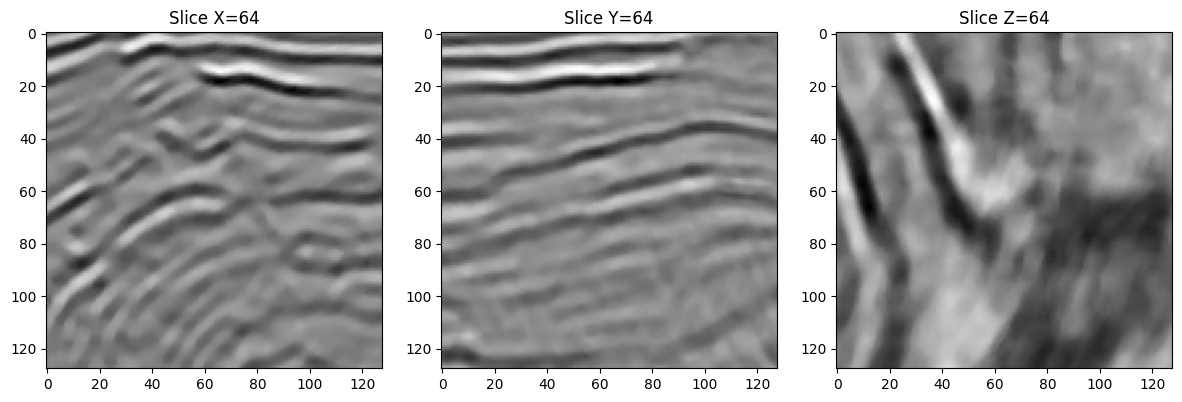

In [6]:
path = df.img_path.values[452]
print(path)

img = getDAT(path)
print(np.min(img), np.max(img), np.mean(img), np.std(img))
showTile(img=img)

In [7]:
class PredictDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        img  = getDAT(row.img_path)
        img_tensor  = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        return (img_tensor)


predictDataset = PredictDataset(df)
predictLoader  = DataLoader(
    predictDataset, 
    batch_size=1,
    shuffle=False, 
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

In [ ]:
for model_name in models:
    model_path = f'Backup/{model_name}' 
    
    with open(f'{model_path}/info.json', 'r', encoding='utf-8') as f:
        modelInfo = json.load(f)

    modelOptions = modelInfo.get('model', {})
    print(f"\n[{model_name}] Model Options:")
    print(json.dumps(modelOptions, indent=4))

    network   = ModelNetwork(**modelOptions)
    modelData = torch.load(f'{model_path}/model.pth')

    network.model.load_state_dict(modelData['model'])
    network.model.eval()
    network.model.to(network.device)
    print(f"Weights from {model_path} loaded successfully!")

    # 1. Nova estrutura de diretórios aninhados (marlim -> images/masks -> dat/npy/show)
    base_marlim = os.path.join(model_path, 'marlim')
    
    # Caminhos para Images
    img_dat_dir  = os.path.join(base_marlim, 'images', 'dat')
    img_npy_dir  = os.path.join(base_marlim, 'images', 'npy')
    img_show_dir = os.path.join(base_marlim, 'images', 'show')
    
    # Caminhos para Masks
    mask_dat_dir  = os.path.join(base_marlim, 'masks', 'dat')
    mask_npy_dir  = os.path.join(base_marlim, 'masks', 'npy')
    mask_show_dir = os.path.join(base_marlim, 'masks', 'show')
    
    # Cria todas as pastas de uma vez
    for d in [img_dat_dir, img_npy_dir, img_show_dir, mask_dat_dir, mask_npy_dir, mask_show_dir]:
        os.makedirs(d, exist_ok=True)

    print(f"Iniciando predições e salvamento para {model_name}...")

    # 2. Loop de inferência
    with torch.no_grad():
        for index, img_tensor in enumerate(tqdm(predictLoader)):
            
            # Extrai o nome do arquivo
            orig_path = df.iloc[index]['img_path']
            base_name = os.path.basename(orig_path).replace('.dat', '')
            
            filename_npy = f"{base_name}.npy"
            filename_dat = f"{base_name}.dat"
            filename_png = f"{base_name}.png"

            # Move para o device e infere
            img_batch = img_tensor.to(network.device)
            logits = network.model(img_batch)

            # Probabilidades e máscara para os plots
            if hasattr(network, 'multiclass') and network.multiclass:
                probs = torch.softmax(logits, dim=1)
                pred_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()
            else:
                probs = torch.sigmoid(logits)
                pred_mask = (probs > 0.5).squeeze().cpu().numpy()

            # Converte para float32
            img_np   = img_tensor.squeeze().cpu().numpy().astype(np.float32)
            probs_np = probs.squeeze().cpu().numpy().astype(np.float32)
            
            # 3. Salva em disco (.dat e .npy)
            img_np.tofile(os.path.join(img_dat_dir, filename_dat))
            np.save(os.path.join(img_npy_dir, filename_npy), img_np)
            
            probs_np.tofile(os.path.join(mask_dat_dir, filename_dat))
            np.save(os.path.join(mask_npy_dir, filename_npy), probs_np)
            
            # 4. Preparação para as imagens PNG (show)
            imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
            is_pred = (pred_mask > 0)

            # --- A. Salva a sobreposição em images/show ---
            overlay = imgRgb.copy()
            overlay[is_pred] = [255, 0, 0] # Vermelho
            
            alpha = 0.5
            result_vis = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
            
            # --- B. Salva puramente a máscara em masks/show ---
            maskRgb = np.zeros_like(imgRgb) # Fundo preto
            maskRgb[is_pred] = [255, 0, 0]  # Pinta a predição de vermelho
    
    print(f"Predições para {model_name} salvas com sucesso na estrutura 'marlim'!\n")


[model_1] Model Options:
{
    "network": "unet3d_v2",
    "img_size": [
        128,
        128,
        128
    ],
    "classes": 1,
    "channels": 1,
    "dropout": 0.1,
    "num_filters": 16,
    "lr": 0.001
}
Weights from Backup/model_1 loaded successfully!
Iniciando predições e salvamento para model_1...


100%|██████████| 910/910 [16:28<00:00,  1.09s/it]  


Predições para model_1 salvas com sucesso na estrutura 'marlim'!


[model_2] Model Options:
{
    "network": "unet3d_v2",
    "img_size": [
        128,
        128,
        128
    ],
    "classes": 1,
    "channels": 1,
    "dropout": 0.1,
    "num_filters": 16,
    "lr": 0.001
}
Weights from Backup/model_2 loaded successfully!
Iniciando predições e salvamento para model_2...


100%|██████████| 910/910 [11:05<00:00,  1.37it/s]


Predições para model_2 salvas com sucesso na estrutura 'marlim'!


[model_3] Model Options:
{
    "network": "standard",
    "img_size": [
        128,
        128,
        128
    ],
    "classes": 1,
    "channels": 1,
    "dropout": 0.1,
    "num_filters": 16,
    "lr": 0.001
}
Weights from Backup/model_3 loaded successfully!
Iniciando predições e salvamento para model_3...


100%|██████████| 910/910 [07:10<00:00,  2.11it/s]


Predições para model_3 salvas com sucesso na estrutura 'marlim'!


[model_4] Model Options:
{
    "network": "standard",
    "img_size": [
        128,
        128,
        128
    ],
    "classes": 1,
    "channels": 1,
    "dropout": 0.1,
    "num_filters": 16,
    "lr": 0.001
}
Weights from Backup/model_4 loaded successfully!
Iniciando predições e salvamento para model_4...


 63%|██████▎   | 575/910 [04:45<02:50,  1.97it/s]